# PointillHist on a simulated skin section

This notebook maps one spatial transcriptomics section with PointillHist at its default settings
and checks the result against the ground truth. The section comes from **PointillSim**, the
simulation framework described in the manuscript: an 800 × 1000 µm vertical cross-section of
skin with 7 542 cells of 19 types, layered by depth (the four epidermal strata, the
dermo-epidermal junction, the papillary and the reticular dermis, the hypodermis), with hair
follicles and their sebaceous units, eccrine and apocrine glands, vessels, collagen bundles and
perivascular immune infiltrates. Expression follows a hierarchical reference of the 19 types
over 1 000 genes, of which a 200-gene panel is measured. The instance used here belongs to the
gene-sensitivity sweep of the manuscript (sensitivity 0.5, with extra dropout), which leaves
about 19 transcripts and 16 detected genes per cell: a deliberately sparse and hard case.

The data live in `data/skin/`:

| file | content |
|---|---|
| `cells.csv` | one row per cell: centroid `X`, `Y` in µm, the ground-truth `Class ID`, the type probabilities the label was drawn from, the cell shape, and `Color_string`, the colour PointillSim drew the type with (reused in the figures) |
| `dots.csv` | one row per transcript: `x`, `y`, `gene`, and the `cell` it belongs to |
| `cell_type_expression.csv` | the reference: mean expression of the 200 panel genes (rows) in each cell type (columns) |
| `hyperparameters.json` | the PointillSim settings that generated this instance |

In [1]:
# Restart the kernel and run this cell first, before any CUDA use.
# Full determinism for PyTorch Geometric operations may make training slower.
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import numpy as np
import torch

torch.use_deterministic_algorithms(True, warn_only=False)
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)  # Seeds CPU and CUDA.

import ast
import json
import time

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support

import pointillhist as ph

DATA = "data/skin"
OUT = "results"                     # everything this notebook writes; not tracked by git
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 200, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold", "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})

cells = pd.read_csv(f"{DATA}/cells.csv")
dots = pd.read_csv(f"{DATA}/dots.csv")
reference = pd.read_csv(f"{DATA}/cell_type_expression.csv", index_col=0).T     # cell types x genes
with open(f"{DATA}/hyperparameters.json") as f:
    sim = json.load(f)

cell_types = list(reference.index)                    # Class ID i is the i-th cell type of the reference
labels = [t.replace("_", " ") for t in cell_types]    # for the figures
cells["cell_type"] = [cell_types[i] for i in cells["Class ID"]]
cells.index = cells.index.astype(str)                 # cell ids, as referenced by dots["cell"]

# the colour PointillSim drew each type with
palette = {cell_types[i]: to_hex(ast.literal_eval(s.replace("np.float64", ""))[:3])
           for i, s in cells.groupby("Class ID")["Color_string"].first().items()}

print(f"{len(cells):,} cells, {len(dots):,} transcripts, {reference.shape[1]} genes, {reference.shape[0]} cell types")
print(f"PointillSim gene sensitivity {sim['gene_sensitivity']}: median {sim['per_cell_median_transcripts']:.0f} transcripts "
      f"and {sim['per_cell_median_detected_genes']:.0f} detected genes per cell")

/mnt/uplamanno/scratch/alireza/branch_ph/PointillHist/pointillhist/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/mnt/uplamanno/scratch/alireza/branch_ph/PointillHist/pointillhist/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


7,542 cells, 146,419 transcripts, 200 genes, 19 cell types
PointillSim gene sensitivity 0.5: median 19 transcripts and 16 detected genes per cell


## The tissue

Cells coloured by their ground-truth type, with the epidermis at the top; a sample of the
transcripts, coloured by the type of the cell they were assigned to; how many transcripts a
cell carries; and how the 19 types are represented.

findfont: Failed to find font weight semibold, now using 700.


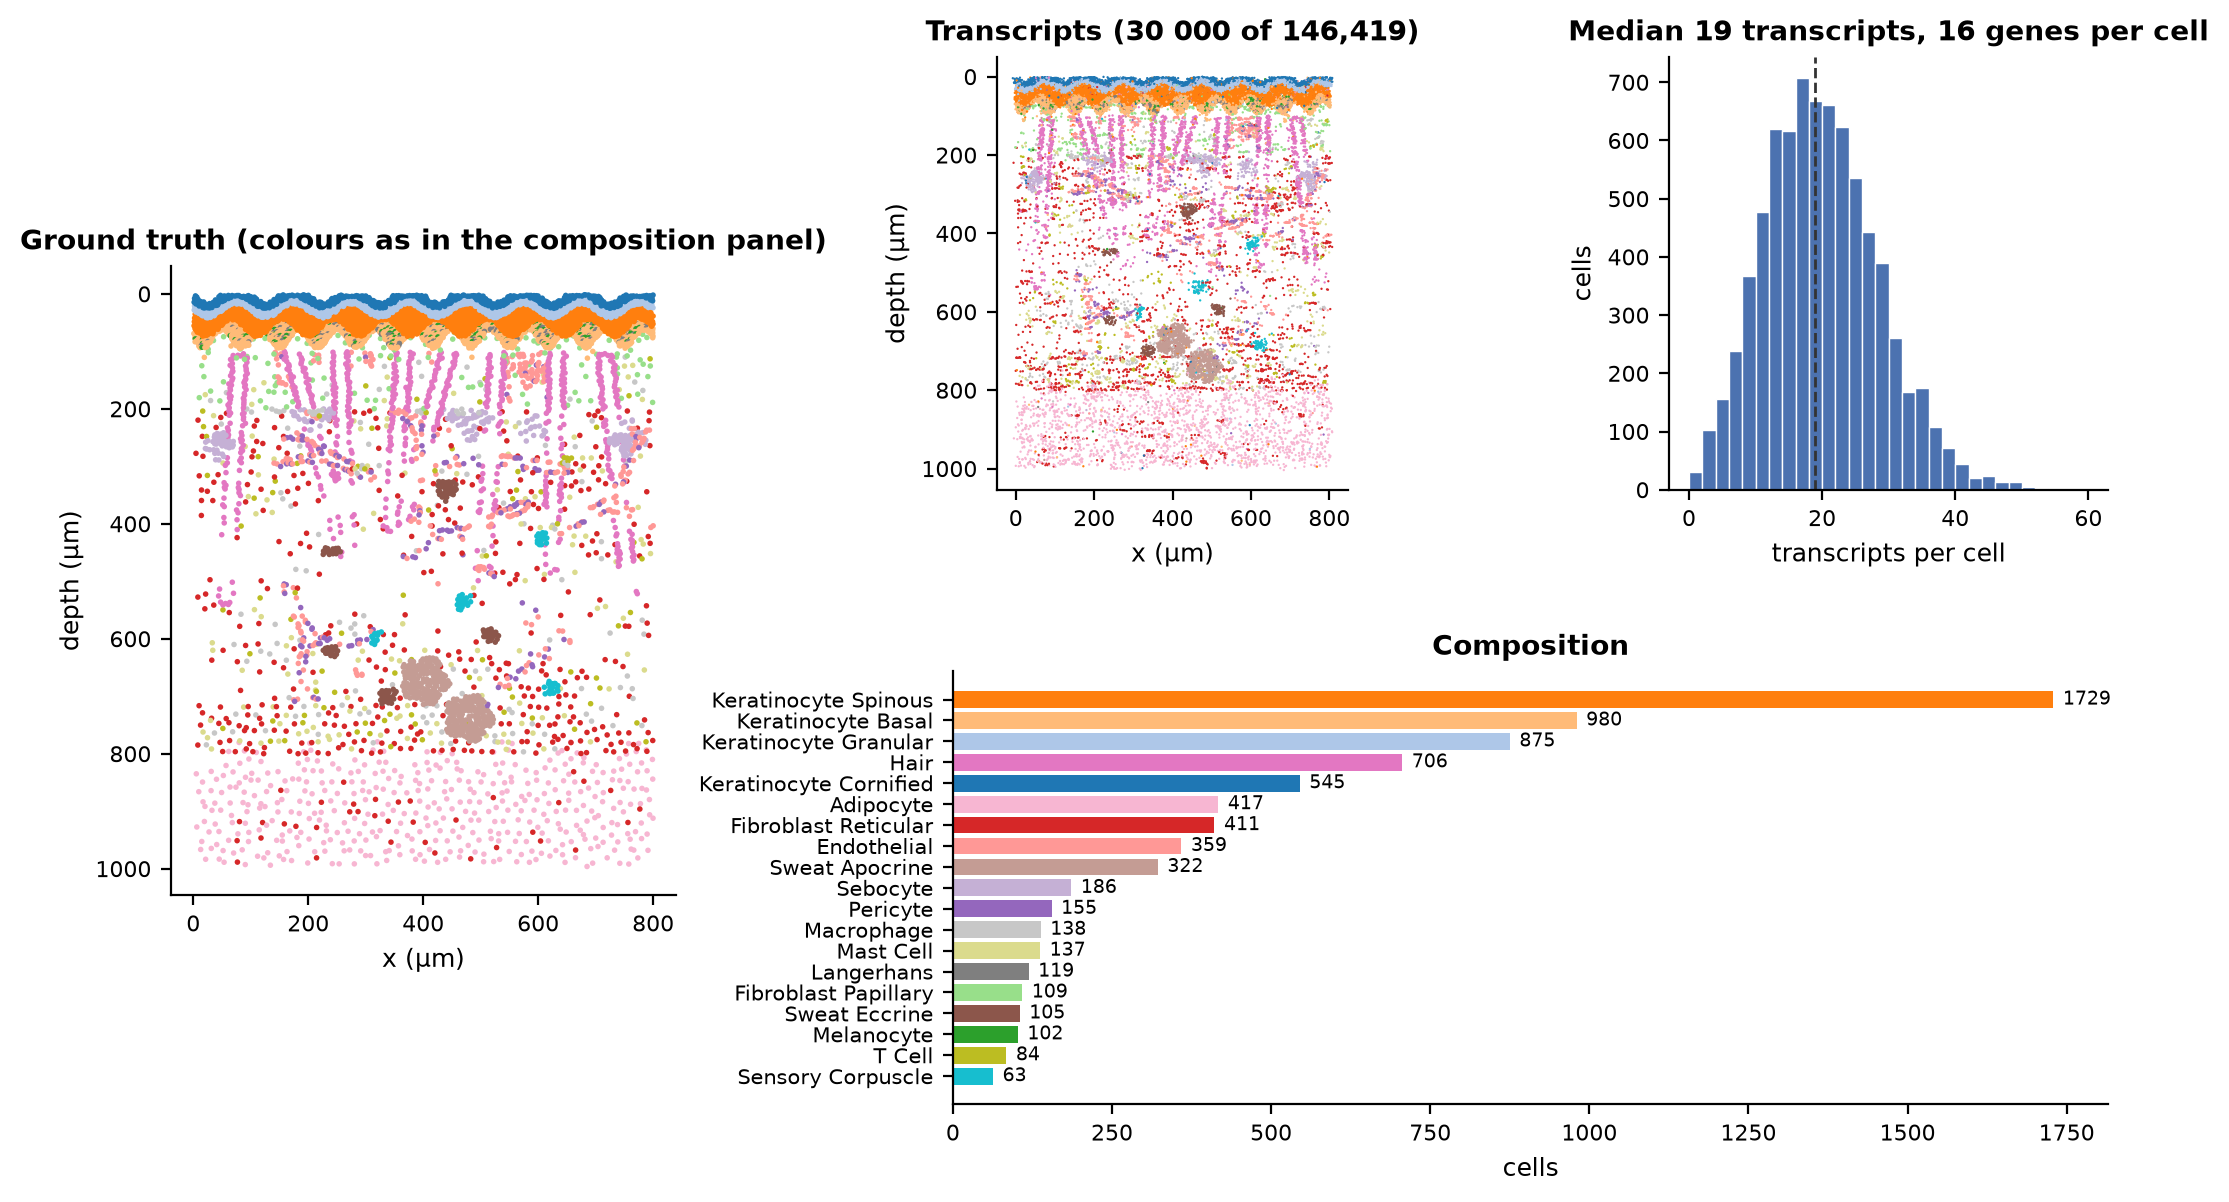

In [2]:
n_transcripts = dots.groupby("cell").size().reindex(range(len(cells)), fill_value=0).to_numpy()
n_genes = dots.groupby("cell")["gene"].nunique().reindex(range(len(cells)), fill_value=0).to_numpy()
cells["n_transcripts"], cells["n_genes"] = n_transcripts, n_genes
type_of_cell = cells["cell_type"].to_numpy()

fig = plt.figure(figsize=(12.5, 6.8))
grid = fig.add_gridspec(2, 3, width_ratios=[1.15, 1, 1], hspace=0.42, wspace=0.6)

ax = fig.add_subplot(grid[:, 0])
ax.scatter(cells["X"], cells["Y"], c=cells["cell_type"].map(palette), s=4, linewidths=0, rasterized=True)
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set(xlabel="x (µm)", ylabel="depth (µm)", title="Ground truth (colours as in the composition panel)")

ax = fig.add_subplot(grid[0, 1])
sample = dots.sample(30_000, random_state=0)
ax.scatter(sample["x"], sample["y"], c=pd.Series(type_of_cell[sample["cell"].to_numpy()]).map(palette),
           s=0.7, linewidths=0, rasterized=True)
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set(xlabel="x (µm)", ylabel="depth (µm)", title=f"Transcripts (30 000 of {len(dots):,})")

ax = fig.add_subplot(grid[0, 2])
ax.hist(n_transcripts, bins=np.arange(0, 62, 2), color="#4C72B0", edgecolor="white", linewidth=0.5)
ax.axvline(np.median(n_transcripts), color="#333333", lw=1, ls="--")
ax.set(xlabel="transcripts per cell", ylabel="cells",
       title=f"Median {np.median(n_transcripts):.0f} transcripts, {np.median(n_genes):.0f} genes per cell")

ax = fig.add_subplot(grid[1, 1:])
counts_by_type = cells["cell_type"].value_counts()
ax.barh(range(len(counts_by_type)), counts_by_type.values, color=[palette[t] for t in counts_by_type.index])
ax.set_yticks(range(len(counts_by_type)))
ax.set_yticklabels([t.replace("_", " ") for t in counts_by_type.index], fontsize=7.5)
ax.invert_yaxis(); ax.set(xlabel="cells", title="Composition")
for i, v in enumerate(counts_by_type.values):
    ax.text(v + 15, i, f"{v}", va="center", fontsize=7)
fig.savefig(f"{OUT}/fig1_tissue.png")

## The reference

PointillHist needs only a table of mean expression per cell type. In this reference the 200
panel genes fall into four classes (housekeeping, lineage, marker and weakly informative), and
several types are transcriptionally close: the keratinocyte strata, the two fibroblast
populations, the two sweat glands and the sebocytes, the immune cells. The similarity matrix,
computed over the lineage and marker genes, shows what the mapping has to tell apart.

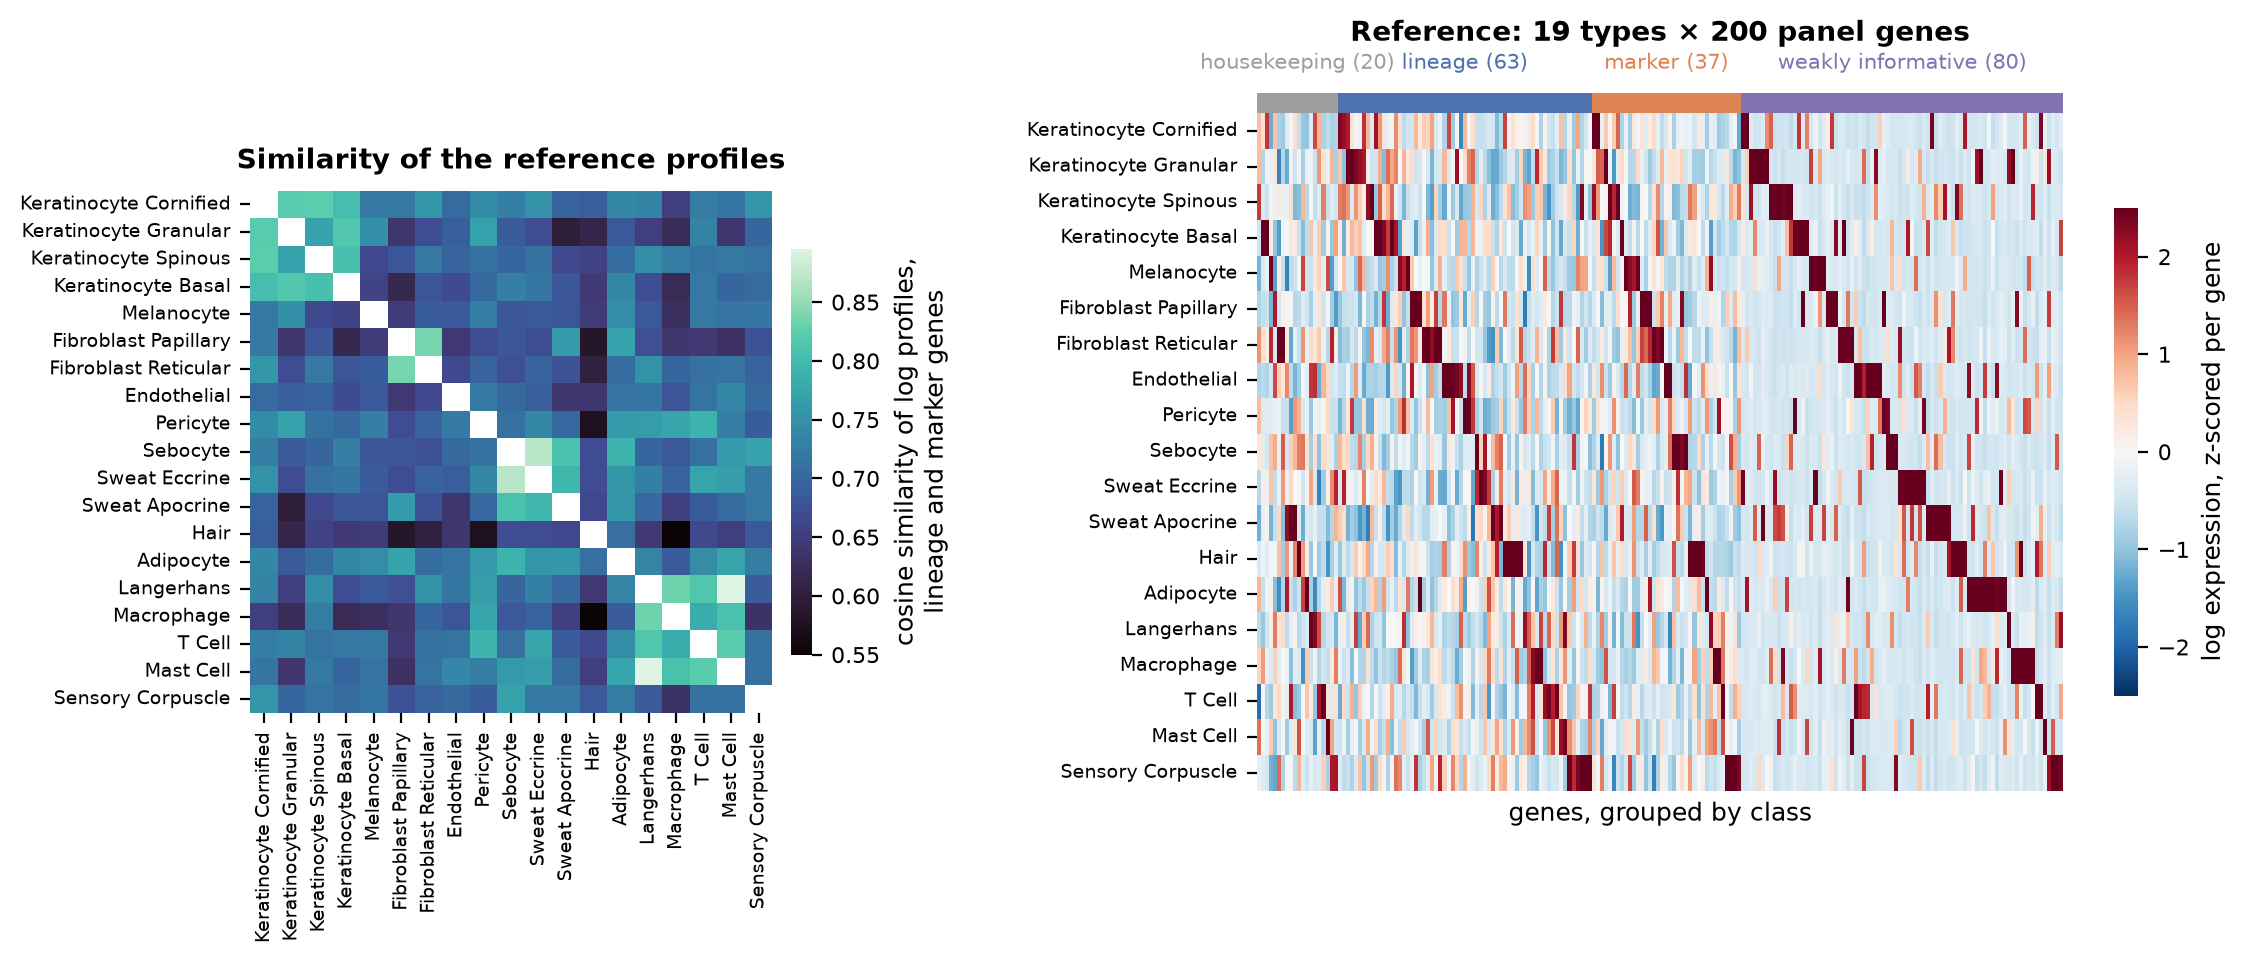

In [3]:
log_ref = np.log1p(reference.to_numpy())

gene_class = pd.Series([g.split("_")[0] for g in reference.columns], index=reference.columns)
class_order = ["HK", "LIN", "MRK", "WEAK"]
class_name = {"HK": "housekeeping", "LIN": "lineage", "MRK": "marker", "WEAK": "weakly informative"}
class_colour = {"HK": "#9e9e9e", "LIN": "#4C72B0", "MRK": "#DD8452", "WEAK": "#8172B3"}
gene_order = [g for c in class_order for g in gene_class.index[gene_class == c]]

# similarity over the lineage and marker genes, which carry the type structure; housekeeping and
# weakly informative genes are shared by every type and only raise the baseline
informative = gene_class.isin(["LIN", "MRK"]).to_numpy()
norms = np.linalg.norm(log_ref[:, informative], axis=1)
similarity = (log_ref[:, informative] @ log_ref[:, informative].T) / np.outer(norms, norms)
diagonal = np.eye(len(cell_types), dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.2, 1.9], "wspace": 0.45})
sns.heatmap(similarity, ax=axes[0], mask=diagonal, cmap="mako", vmin=similarity[~diagonal].min(),
            vmax=similarity[~diagonal].max(), square=True, xticklabels=labels, yticklabels=labels,
            cbar_kws={"shrink": 0.6, "label": "cosine similarity of log profiles,\nlineage and marker genes", "pad": 0.03})
axes[0].set_title("Similarity of the reference profiles", pad=8); axes[0].tick_params(labelsize=7)

z = pd.DataFrame(log_ref, index=cell_types, columns=reference.columns)[gene_order]
z = (z - z.mean()) / (z.std() + 1e-9)                 # per gene, across types
sns.heatmap(z, ax=axes[1], cmap="RdBu_r", vmin=-2.5, vmax=2.5, xticklabels=False, yticklabels=labels,
            cbar_kws={"shrink": 0.72, "label": "log expression, z-scored per gene"})
for c in class_order:
    idx = [i for i, g in enumerate(gene_order) if gene_class[g] == c]
    axes[1].axvspan(idx[0], idx[-1] + 1, ymin=1.0, ymax=1.03, color=class_colour[c], clip_on=False, lw=0)
    axes[1].text((idx[0] + idx[-1] + 1) / 2, -1.1, f"{class_name[c]} ({len(idx)})", ha="center", va="bottom",
                 fontsize=7.5, color=class_colour[c])
axes[1].set_title("Reference: 19 types × 200 panel genes", pad=26)
axes[1].set_xlabel("genes, grouped by class"); axes[1].tick_params(labelsize=7)
fig.savefig(f"{OUT}/fig2_reference.png")

## The section as AnnData

PointillHist reads a section from an `.h5ad` file with raw counts in `X` and the coordinates in
`obsm["spatial"]`, so the transcripts are aggregated per cell into a counts matrix over the
panel genes. The ground truth travels along in `obs` for the evaluation; PointillHist never
looks at it.

In [4]:
counts = (dots.groupby(["cell", "gene"]).size().unstack(fill_value=0)
          .reindex(index=range(len(cells)), columns=reference.columns, fill_value=0))
adata = ad.AnnData(X=counts.to_numpy(dtype=np.float32))
adata.obs_names = cells.index
adata.var_names = reference.columns
adata.obsm["spatial"] = cells[["X", "Y"]].to_numpy()
adata.obs["cell_type"] = cells["cell_type"].to_numpy()

section_path = f"{OUT}/skin_section.h5ad"
adata.write_h5ad(section_path)
adata

AnnData object with n_obs × n_vars = 7542 × 200
    obs: 'cell_type'
    obsm: 'spatial'
    layers: None (.X)

## Mapping with PointillHist

The four calls of the README. Every setting is at its default except two: the count
likelihood is `poisson` instead of `zip`, and the weight of the composition prior is
`lambda_density=10`, the value the [hyperparameter guide](../guide/hyperparameters.md)
recommends for a reference with dozens of types (the default, 100, is meant for references
with hundreds of types; with 19 types it pulls the composition towards uniform and costs eight
to twenty points of accuracy on this section, depending on the seed). The tiling parameters
are `"auto"`, which keeps a
section of this size as one graph; the network runs on the GPU when one is available and on
the CPU otherwise.

In [5]:
# Reset the seeds when rerunning this training cell with a fresh model.
random.seed(SEED)
torch.manual_seed(SEED)          # the network initialisation and the dropout masks
np.random.seed(SEED)             # any NumPy draws in the pipeline
start = time.time()

graphs = ph.pp.generate_graphs([section_path], reference)
net = ph.tr.networks(graphs)
net, history = ph.tr.train(net, graphs, reference, cell_loss_type="poisson", lambda_density=10)
result = ph.eval.predict(net, graphs)

print(f"{len(graphs)} graph(s), {sum(g['cells'].num_nodes for g in graphs):,} cell nodes; "
      f"trained and predicted in {time.time() - start:.0f} s on {next(net.parameters()).device}")

Generating graphs:   0%|          | 0/1 [00:00<?, ?it/s]

Generating graphs: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]

Generating graphs: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]

Initializing (dispersions, distance scalers, optimizer)...


Training:   0%|          | 0/100 [00:00<?, ?it/s]

...

Training: 100%|██████████| 100/100 [00:18<00:00,  5.31it/s, anatomical=0.0000, cell=0.5875, density=0.0111, epoch=100/100, grid=0.4914, lam_anat=0.1000, lam_d=1.0, total=6.3780]

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1/1 [00:00<00:00,  7.16it/s]

Predicting: 100%|██████████| 1/1 [00:00<00:00,  6.95it/s]

1 graph(s), 7,542 cell nodes; trained and predicted in 20 s on cuda:0


`history` holds the loss per epoch and its terms: `cell`, the Poisson likelihood of the counts
of every cell; `grid` and `grid cosine`, the agreement between the composition pooled on the
fine grid and the reference; `density`, the prior on the type composition of the section,
whose weight `lambda_density` is held for the first half of the epochs and then annealed, so
that term is expected to drift late in training.

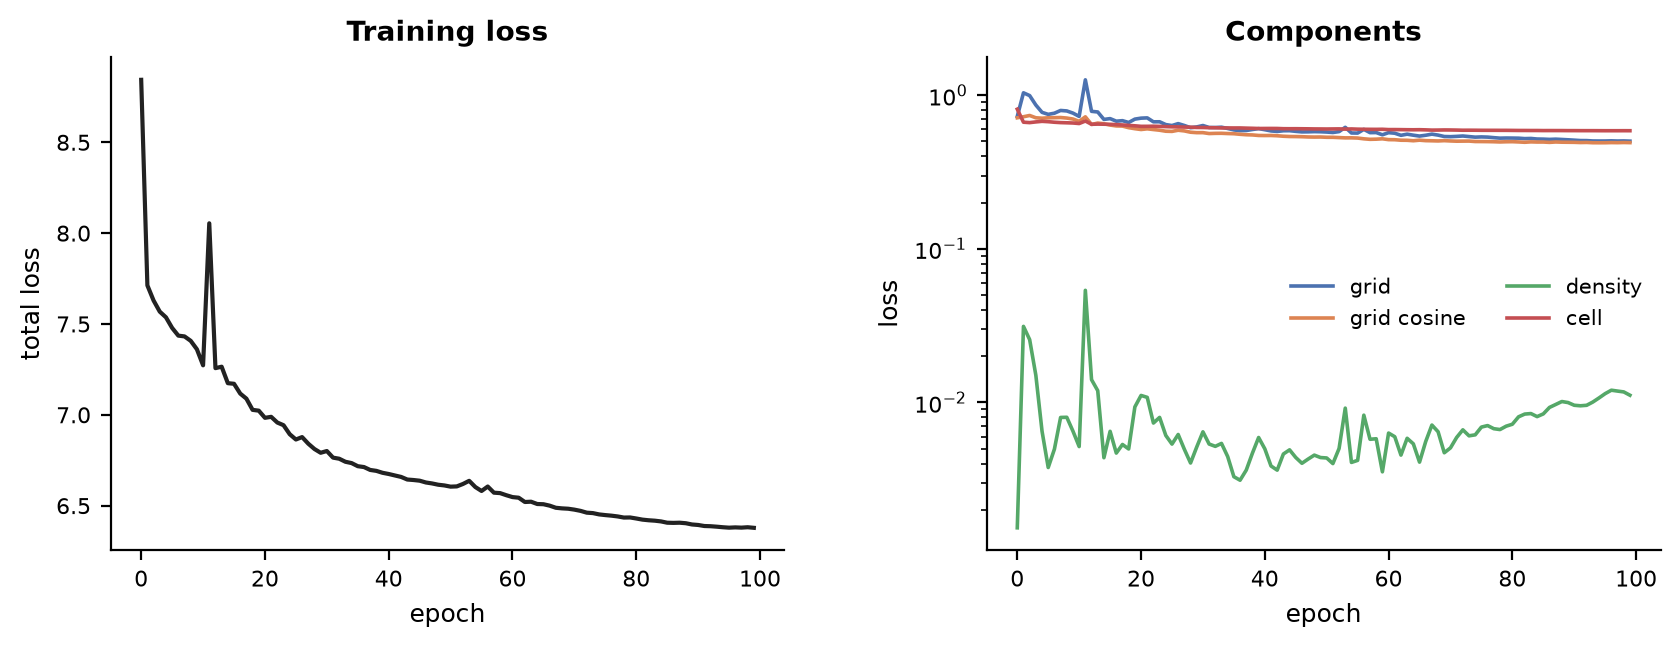

In [6]:
components = {k: np.asarray(v) for k, v in history.items()
              if k.endswith("loss") and k != "total_loss" and np.any(np.asarray(v) != 0)}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={"wspace": 0.3})
axes[0].plot(history["total_loss"], color="#222222", lw=1.5)
axes[0].set(xlabel="epoch", ylabel="total loss", title="Training loss")
for (k, v), colour in zip(components.items(), sns.color_palette("deep", len(components))):
    axes[1].plot(v, lw=1.3, color=colour, label=k.replace("_loss", "").replace("_", " "))
axes[1].set(xlabel="epoch", ylabel="loss", title="Components")
if all(v.min() > 0 for v in components.values()):
    axes[1].set_yscale("log")
axes[1].legend(fontsize=7.5, ncol=2)
fig.savefig(f"{OUT}/fig3_training.png")

## Accuracy against the ground truth

`predict` returns one type per cell in the order of `unique_cell_ids`, which are the
`obs_names` of the section, so the predictions align with the cells by name.

In [7]:
pred = pd.Series(result["all_cell_types"], index=pd.Index(result["unique_cell_ids"]).astype(str)).reindex(adata.obs_names)
assert pred.notna().all(), "every cell should receive a prediction"
truth = pd.Series(adata.obs["cell_type"].to_numpy(), index=adata.obs_names)
cells["predicted"] = pred.to_numpy()
cells["correct"] = cells["predicted"] == cells["cell_type"]

accuracy = accuracy_score(truth, pred)
summary = {"accuracy": accuracy}
for average in ("macro", "weighted"):
    p, r, f, _ = precision_recall_fscore_support(truth, pred, average=average, zero_division=0)
    summary[f"F1 ({average})"] = f
    summary[f"precision ({average})"] = p
    summary[f"recall ({average})"] = r
pd.Series(summary, name="PointillHist").to_frame().round(3)

,PointillHist
accuracy,0.931
F1 (macro),0.863
precision (macro),0.888
recall (macro),0.854
F1 (weighted),0.928
precision (weighted),0.932
recall (weighted),0.931


Ground truth and prediction side by side.

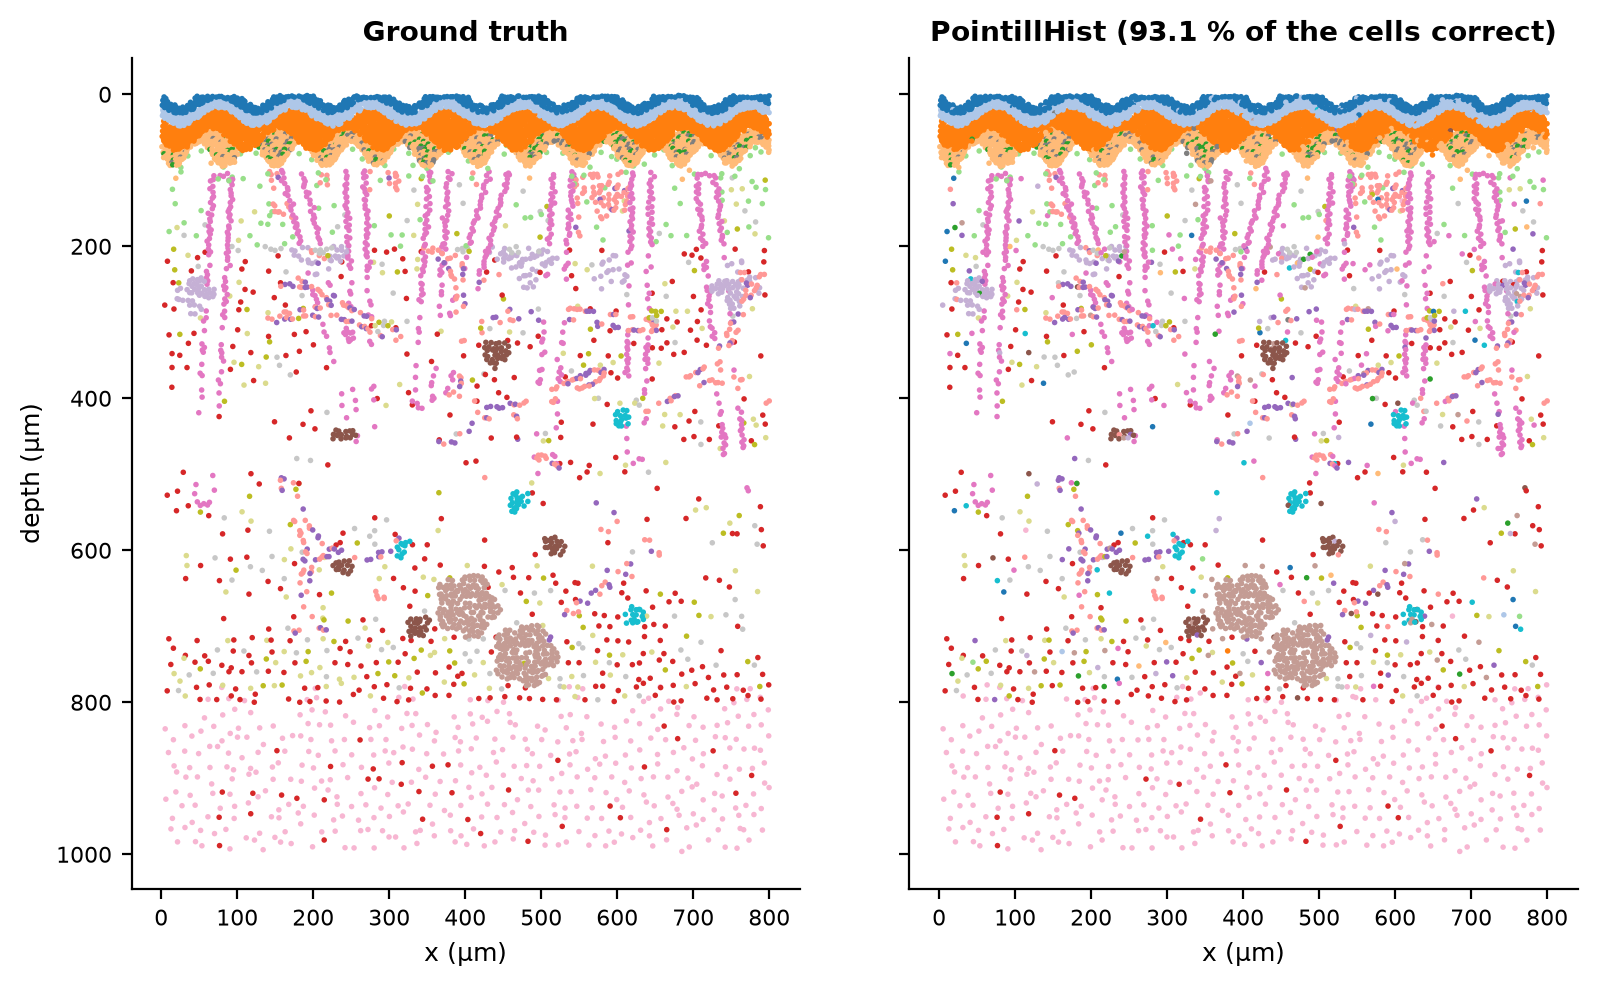

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 5.4), sharex=True, sharey=True, gridspec_kw={"wspace": 0.12})
titles = ["Ground truth", f"PointillHist ({100 * accuracy:.1f} % of the cells correct)"]
for ax, column, title in zip(axes, ["cell_type", "predicted"], titles):
    ax.scatter(cells["X"], cells["Y"], c=cells[column].map(palette), s=4, linewidths=0, rasterized=True)
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xlabel("x (µm)")
axes[0].set_ylabel("depth (µm)"); axes[0].invert_yaxis()
fig.savefig(f"{OUT}/fig4_maps.png")

The confusion matrix shows which types are exchanged, and the per-type scores which of them
carry the errors: the four immune types and the two fibroblast populations, 13 % of the cells
and about 60 % of the errors. The exchanges follow the tissue rather than the similarity of the
reference profiles: Langerhans cells and melanocytes, the minorities scattered through the
basal layer, are absorbed by basal keratinocytes (about one in five and one in seven of them,
the largest entries off the diagonal); reticular fibroblasts and mast cells go to the follicles,
adipocytes, glands and vessels they sit among; the two fibroblast populations are almost never
taken for each other.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


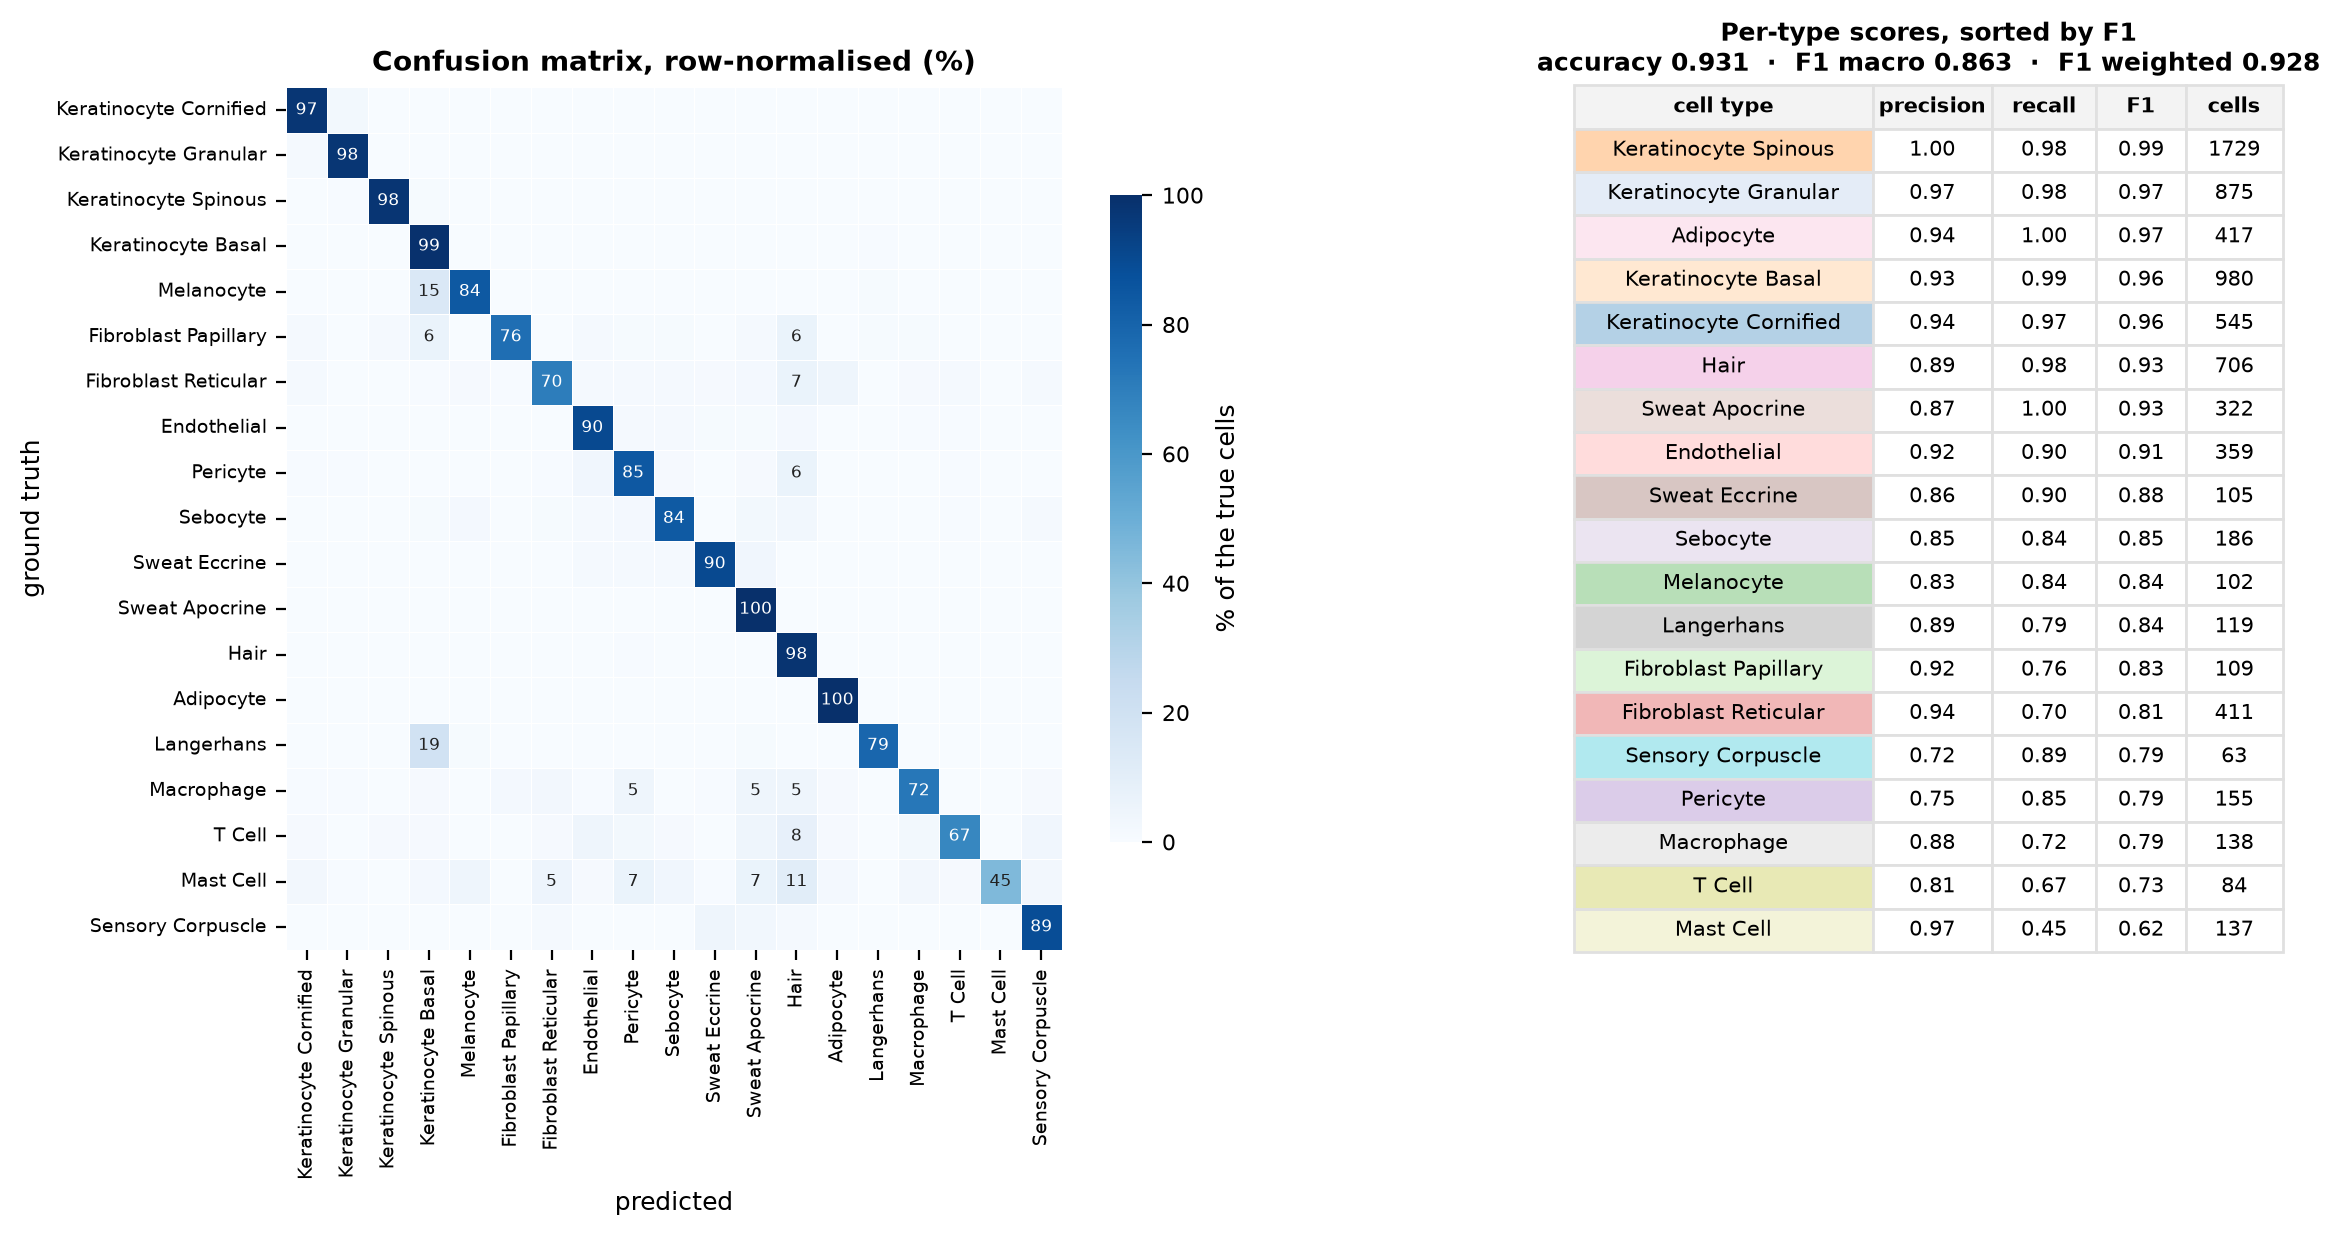

In [9]:
p, r, f, support = precision_recall_fscore_support(truth, pred, labels=cell_types, zero_division=0)
per_type = (pd.DataFrame({"precision": p, "recall": r, "F1": f, "cells": support}, index=cell_types)
            .sort_values("F1", ascending=False))
cm = confusion_matrix(truth, pred, labels=cell_types)
cm_row = 100 * cm / cm.sum(axis=1, keepdims=True)          # row-normalised, in %

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [1.3, 1], "wspace": 0.35})
sns.heatmap(cm_row, ax=axes[0], cmap="Blues", vmin=0, vmax=100, xticklabels=labels,
            yticklabels=labels, linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.75, "label": "% of the true cells", "ticks": [0, 20, 40, 60, 80, 100]})
for i in range(len(cell_types)):                          # annotate the diagonal and every confusion of at least 5 %
    for j in range(len(cell_types)):
        if i == j or cm_row[i, j] >= 5:
            axes[0].text(j + 0.5, i + 0.5, f"{cm_row[i, j]:.0f}", ha="center", va="center", fontsize=6,
                         color="white" if cm_row[i, j] > 60 else "#222222")
axes[0].set(xlabel="predicted", ylabel="ground truth", title="Confusion matrix, row-normalised (%)")
axes[0].tick_params(labelsize=7)

# the per-type scores as a table next to the matrix, one row per type, sorted by F1
ax = axes[1]
ax.axis("off")
rows = [[t.replace("_", " "), f"{row.precision:.2f}", f"{row.recall:.2f}", f"{row.F1:.2f}", f"{int(row.cells)}"]
        for t, row in per_type.iterrows()]
table = ax.table(cellText=rows, colLabels=["cell type", "precision", "recall", "F1", "cells"], loc="center",
                 cellLoc="center", colWidths=[0.4, 0.16, 0.14, 0.12, 0.13])
table.auto_set_font_size(False); table.set_fontsize(7.5); table.scale(1, 1.3)
for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor("#e0e0e0")
    if i == 0:
        cell.set_text_props(weight="semibold"); cell.set_facecolor("#f3f3f3")
    elif j == 0:
        cell.set_facecolor(palette[per_type.index[i - 1]] + "55")      # a tint of the type's colour
ax.set_title(f"Per-type scores, sorted by F1\naccuracy {accuracy:.3f}  ·  F1 macro {summary['F1 (macro)']:.3f}  ·  "
             f"F1 weighted {summary['F1 (weighted)']:.3f}", fontsize=9)
fig.savefig(f"{OUT}/fig5_confusion.png")

In [10]:
cells[["X", "Y", "cell_type", "predicted", "correct", "n_transcripts"]].to_csv(f"{OUT}/predictions.csv")
print(f"accuracy {accuracy:.3f}; predictions and figures in {os.path.abspath(OUT)}")

accuracy 0.931; predictions and figures in /mnt/uplamanno/scratch/alireza/branch_ph/PointillHist/pointillhist/examples/results


## Where to go from here

The [hyperparameter guide](../guide/hyperparameters.md) explains the few settings worth
changing for other tissues and panels. `minimal.py` in this folder demonstrates the optional
inputs in one run (several sections with timepoint labels, per-cell regions for the anatomical
prior, expected proportions as the type prior), and the two other examples map real datasets of
more than a million cells: the ABCA-2 MERFISH atlas of the mouse brain
(`train_abca2_supertype.py`) and a whole Xenium section of a newborn mouse
(`p1pup_mapping.ipynb`).